In [8]:
import pystac_client
import planetary_computer
import matplotlib.pyplot as plt
import odc.stac
import numpy as np
from pystac.extensions.eo import EOExtension as eo

In [126]:
NAN_VALUE = -9999

In [127]:
def min_max_normalize(arr: np.ndarray) -> np.ndarray:
    arr = np.where(arr == NAN_VALUE, np.nan, arr)
    # nanmin/nanmax ignore NaN values within an array while still calculating the value (max, min)
    return (arr - np.nanmin(arr)) / (np.nanmax(arr) - np.nanmin(arr))


In [128]:
# rainbow lake alberta
LATITUDE = 58.4999
LONGITUDE = - 119.3995



In [169]:


catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

## Burn Month Data 

Landsat data initial burn site 

In [11]:
bbox_of_interest = [-119.781568, 58.426909, -119.029878, 58.784265]

time_of_interest_burn = "2023-05-01/2023-06-15"

In [181]:
search = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=bbox_of_interest,
    datetime=time_of_interest_burn,
    query={"eo:cloud_cover": {"lt": 10}},
)

items = search.item_collection()
print(f"Returned {len(items)} Items")

Returned 9 Items


In [182]:
selected_item = min(items, key=lambda item: eo.ext(item).cloud_cover)

print(
    f"Choosing {selected_item.id} from {selected_item.datetime.date()}"
    + f" with {selected_item.properties['eo:cloud_cover']}% cloud cover"
)

Choosing LC09_L2SP_047019_20230527_02_T1 from 2023-05-27 with 0.58% cloud cover


In [183]:
max_key_length = len(max(selected_item.assets, key=len))
for key, asset in selected_item.assets.items():
    print(f"{key.rjust(max_key_length)}: {asset.title}")

              qa: Surface Temperature Quality Assessment Band
             ang: Angle Coefficients File
             red: Red Band
            blue: Blue Band
            drad: Downwelled Radiance Band
            emis: Emissivity Band
            emsd: Emissivity Standard Deviation Band
            trad: Thermal Radiance Band
            urad: Upwelled Radiance Band
           atran: Atmospheric Transmittance Band
           cdist: Cloud Distance Band
           green: Green Band
           nir08: Near Infrared Band 0.8
          lwir11: Surface Temperature Band
          swir16: Short-wave Infrared Band 1.6
          swir22: Short-wave Infrared Band 2.2
         coastal: Coastal/Aerosol Band
         mtl.txt: Product Metadata File (txt)
         mtl.xml: Product Metadata File (xml)
        mtl.json: Product Metadata File (json)
        qa_pixel: Pixel Quality Assessment Band
       qa_radsat: Radiometric Saturation and Terrain Occlusion Quality Assessment Band
      qa_aerosol: Aeros

In [194]:
bands_of_interest = ["nir08", "red", "green", "blue"]
data = odc.stac.stac_load(
    [selected_item], bands=bands_of_interest, bbox=bbox_of_interest
).isel(time=0)
data

<xarray.Dataset> Size: 17MB
Dimensions:      (y: 1379, x: 1504)
Coordinates:
  * y            (y) float64 11kB 6.519e+06 6.519e+06 ... 6.478e+06 6.478e+06
  * x            (x) float64 12kB 3.376e+05 3.376e+05 ... 3.826e+05 3.826e+05
    spatial_ref  int32 4B 32611
    time         datetime64[ns] 8B 2023-05-27T18:58:07.682458
Data variables:
    nir08        (y, x) uint16 4MB 0 0 0 0 0 0 ... 17046 17060 16658 16524 17641
    red          (y, x) uint16 4MB 0 0 0 0 0 0 ... 8612 8581 8736 8919 9036 9122
    green        (y, x) uint16 4MB 0 0 0 0 0 0 ... 9850 9941 10112 10220 10309
    blue         (y, x) uint16 4MB 0 0 0 0 0 0 ... 8166 8155 8238 8417 8477 8501

### Example of Burn 

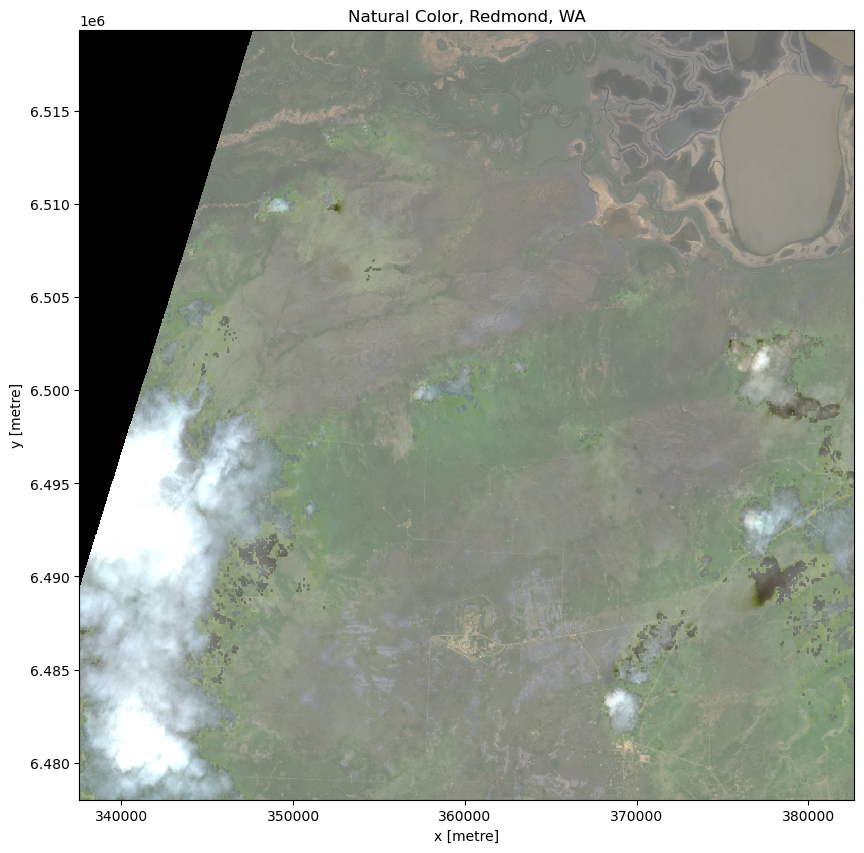

In [189]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))

data[["red", "green", "blue"]].to_array().plot.imshow(robust=True, ax=ax)
ax.set_title("Natural Color, Rainbow Lake, AB");

In [201]:

burn_data = []

for item in items:
    item_id = item.id
    bands_of_interest = ["nir08", "red", "green", "blue", "qa_pixel"]
    data = odc.stac.stac_load(
        [item], bands=bands_of_interest, bbox=bbox_of_interest
    ).isel(time=0)

    burn_data.append(data)

        


### NDVI and Infrared images

## Regrowth of Burn Site

Landsat data from after burn to end of 2024

In [ ]:
time_of_interest_regrowth = "2024-05-01/2024-09-31"

In [ ]:
search = catalog.search(
    collections=["landsat-c2-l2"],
    bbox=bbox_of_interest,
    datetime=time_of_interest_regrowth,
    query={"eo:cloud_cover": {"lt": 10}},
)

items = search.item_collection()
print(f"Returned {len(items)} Items")

In [ ]:
selected_item = min(items, key=lambda item: eo.ext(item).cloud_cover)

print(
    f"Choosing {selected_item.id} from {selected_item.datetime.date()}"
    + f" with {selected_item.properties['eo:cloud_cover']}% cloud cover"
)

In [ ]:
max_key_length = len(max(selected_item.assets, key=len))
for key, asset in selected_item.assets.items():
    print(f"{key.rjust(max_key_length)}: {asset.title}")

### Example Image of Regrowth

In [ ]:
bands_of_interest = ["nir08", "red", "green", "blue"]
data = odc.stac.stac_load(
    [selected_item], bands=bands_of_interest, bbox=bbox_of_interest
).isel(time=0)
data

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(10, 10))

data[["red", "green", "blue"]].to_array().plot.imshow(robust=True, ax=ax)
ax.set_title("Natural Color, Rainbow Lake, AB");

In [ ]:
regrowth_data = []

for item in items:
    item_id = item.id
    bands_of_interest = ["nir08", "red", "green", "blue"]
    data = odc.stac.stac_load(
        [item], bands=bands_of_interest, bbox=bbox_of_interest
    ).isel(time=0)

    regrowth_data.append(data)

        

### NDVI and Infrared images

## MODIS Data

In [9]:
modis_time_of_interest_burn = "2023-05-01/2023-05-31"

In [17]:
modis_catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

search = modis_catalog.search(
        collections=["modis-64A1-061"],
        bbox = bbox_of_interest,
        datetime=modis_time_of_interest_burn,
    )

items = search.item_collection()
print(f"Returned {len(items)} Items")

Returned 2 Items


In [22]:
item = items[1]

In [25]:
data = odc.stac.load(
    items,
    crs="EPSG:3857",
    bbox=bbox_of_interest,
    bands="FireMask",
    resolution=1000,
)
data

TypeError: 'Item' object is not iterable